# Taller: De Pixels a Coordenadas - Explorando la Imagen como Matriz

Este notebook explora cómo se representa una imagen digital como una matriz numérica y cómo manipular sus componentes a nivel de píxel.

In [1]:
%pip install opencv-python-headless numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 6.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Crear carpetas si no existen
os.makedirs('../media', exist_ok=True)

# Ruta de la imagen de entrada
INPUT_IMAGE = '../media/input_image.jpg'

## 1. Cargar una imagen en color

Imagen cargada: (3840, 5760, 3)


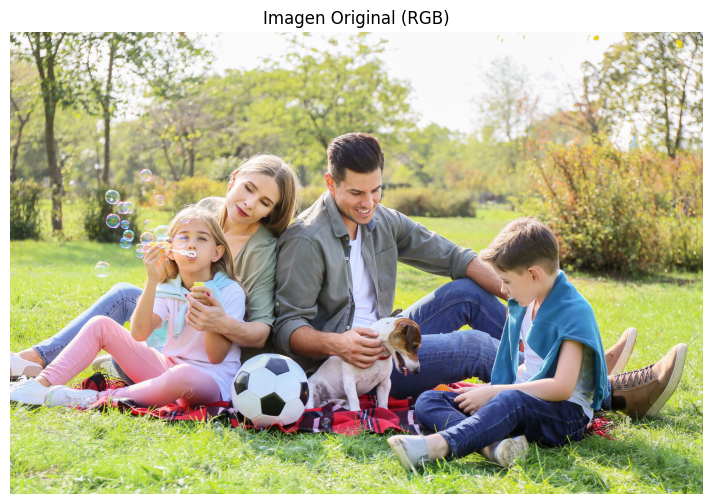

In [3]:
# Cargar imagen en color (BGR por defecto en OpenCV)
img_bgr = cv2.imread(INPUT_IMAGE)

if img_bgr is None:
    # Si no existe, crear una imagen de ejemplo
    img_bgr = np.zeros((400, 600, 3), dtype=np.uint8)
    # Crear un gradiente de color
    for i in range(400):
        for j in range(600):
            img_bgr[i, j] = [i % 256, j % 256, (i + j) % 256]
    print("Imagen creada como ejemplo")
else:
    print(f"Imagen cargada: {img_bgr.shape}")

# Convertir a RGB para matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar imagen original
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('Imagen Original (RGB)')
plt.axis('off')
plt.savefig('../media/01_original_image.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Acceder y mostrar los canales RGB y HSV por separado

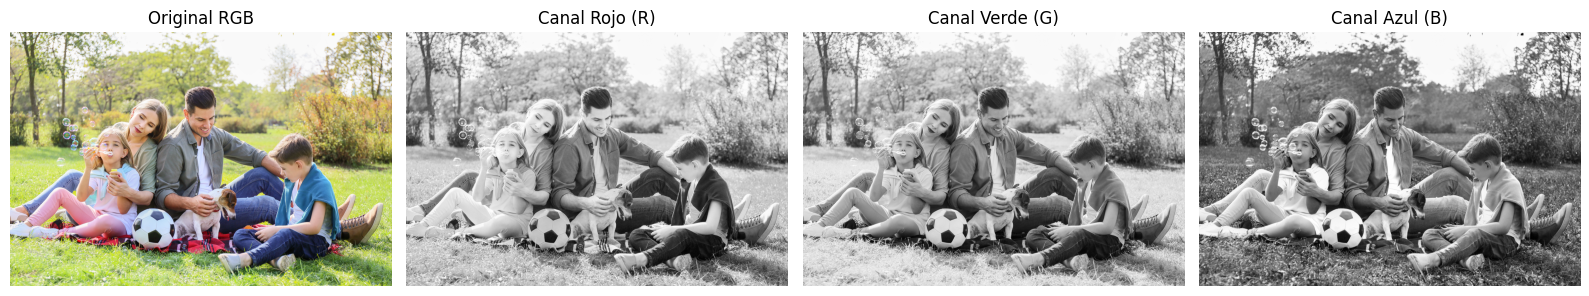

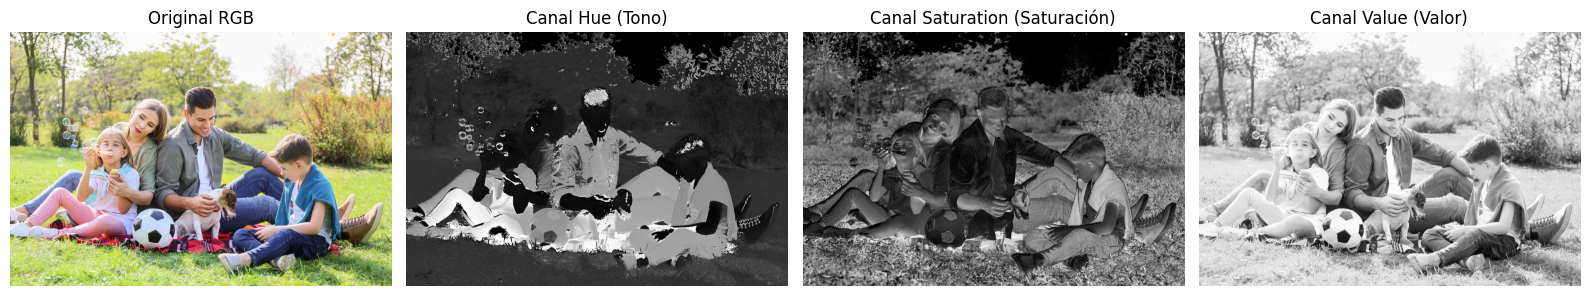

Dimensiones de la imagen: (3840, 5760, 3)
Canal R - Valor medio: 168.93
Canal G - Valor medio: 167.29
Canal B - Valor medio: 134.61
Canal H - Valor medio: 51.25
Canal S - Valor medio: 83.07
Canal V - Valor medio: 181.68


In [4]:
# Separar canales RGB
b, g, r = cv2.split(img_bgr)

# Convertir a HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

# Mostrar canales RGB
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(r, cmap='gray')
axes[1].set_title('Canal Rojo (R)')
axes[1].axis('off')

axes[2].imshow(g, cmap='gray')
axes[2].set_title('Canal Verde (G)')
axes[2].axis('off')

axes[3].imshow(b, cmap='gray')
axes[3].set_title('Canal Azul (B)')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('../media/02_rgb_channels.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar canales HSV
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(h, cmap='gray')
axes[1].set_title('Canal Hue (Tono)')
axes[1].axis('off')

axes[2].imshow(s, cmap='gray')
axes[2].set_title('Canal Saturation (Saturación)')
axes[2].axis('off')

axes[3].imshow(v, cmap='gray')
axes[3].set_title('Canal Value (Valor)')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('../media/03_hsv_channels.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dimensiones de la imagen: {img_bgr.shape}")
print(f"Canal R - Valor medio: {r.mean():.2f}")
print(f"Canal G - Valor medio: {g.mean():.2f}")
print(f"Canal B - Valor medio: {b.mean():.2f}")
print(f"Canal H - Valor medio: {h.mean():.2f}")
print(f"Canal S - Valor medio: {s.mean():.2f}")
print(f"Canal V - Valor medio: {v.mean():.2f}")

## 3. Utilizar slicing de matrices para modificar regiones específicas

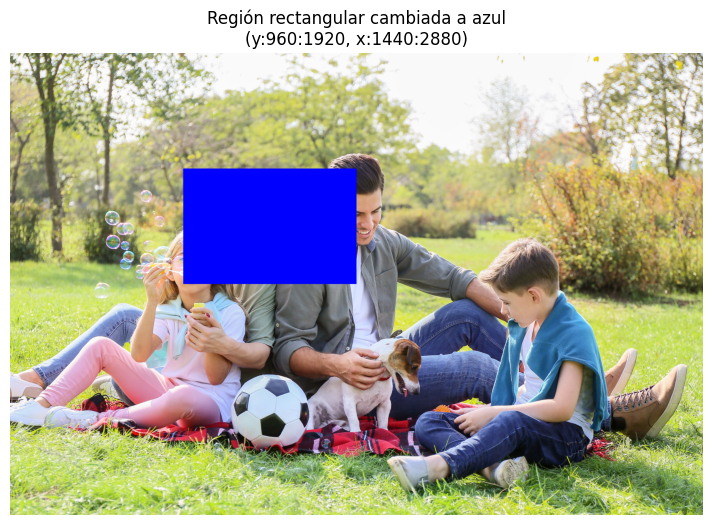

Región modificada: filas 960-1920, columnas 1440-2880


In [5]:
# Crear copia para modificar
img_modified = img_bgr.copy()

# Definir región rectangular (cambiar color a un área)
height, width = img_modified.shape[:2]
y_start, y_end = height // 4, height // 2
x_start, x_end = width // 4, width // 2

# Cambiar color de un área rectangular a azul (BGR)
img_modified[y_start:y_end, x_start:x_end] = [255, 0, 0]

# Mostrar resultado
img_modified_rgb = cv2.cvtColor(img_modified, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(img_modified_rgb)
plt.title(f'Región rectangular cambiada a azul\n(y:{y_start}:{y_end}, x:{x_start}:{x_end})')
plt.axis('off')
plt.savefig('../media/04_region_color_change.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Región modificada: filas {y_start}-{y_end}, columnas {x_start}-{x_end}")

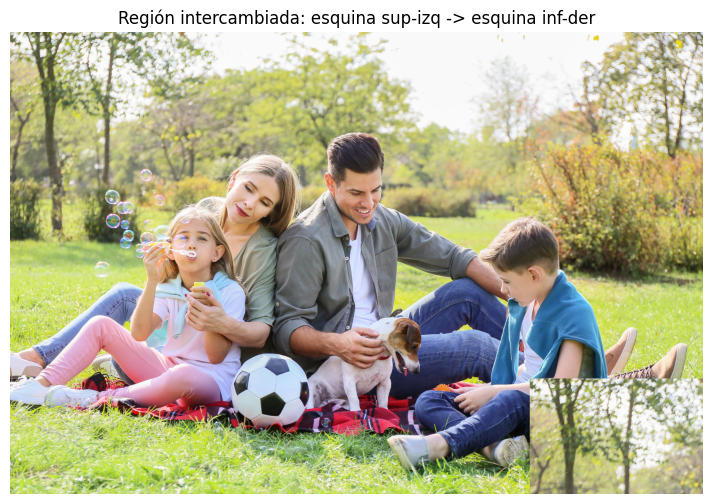

Región intercambiada exitosamente


In [6]:
# Sustituir una región por otra parte de la imagen
img_region_swap = img_bgr.copy()

# Definir dos regiones
region_height = height // 4
region_width = width // 4

# Región origen (esquina superior izquierda)
src_region = img_bgr[0:region_height, 0:region_width].copy()

# Región destino (esquina inferior derecha)
dst_y = height - region_height
dst_x = width - region_width
img_region_swap[dst_y:dst_y+region_height, dst_x:dst_x+region_width] = src_region

# Mostrar resultado
img_region_swap_rgb = cv2.cvtColor(img_region_swap, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(img_region_swap_rgb)
plt.title(f'Región intercambiada: esquina sup-izq -> esquina inf-der')
plt.axis('off')
plt.savefig('../media/05_region_swap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Región intercambiada exitosamente")

## 4. Calcular y visualizar el histograma de intensidades

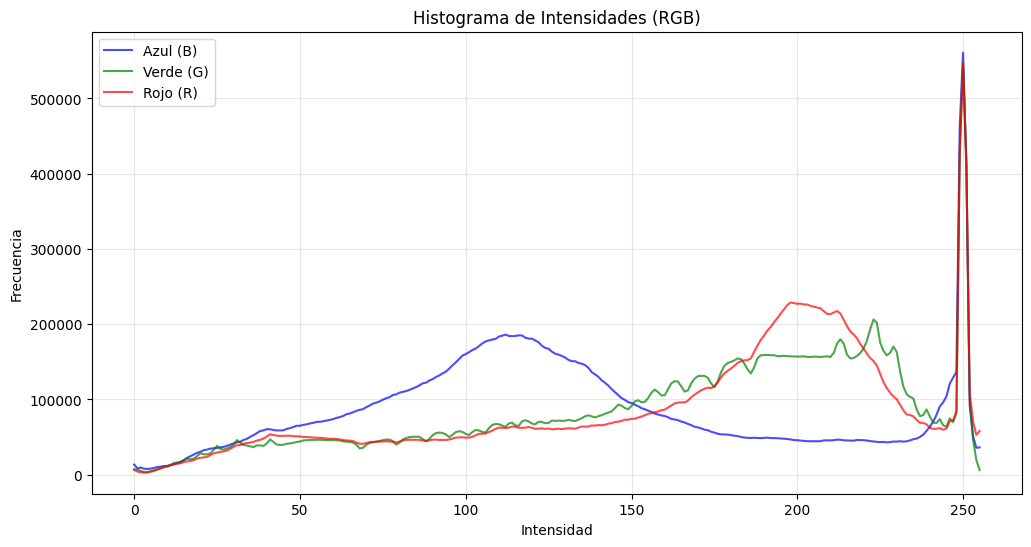

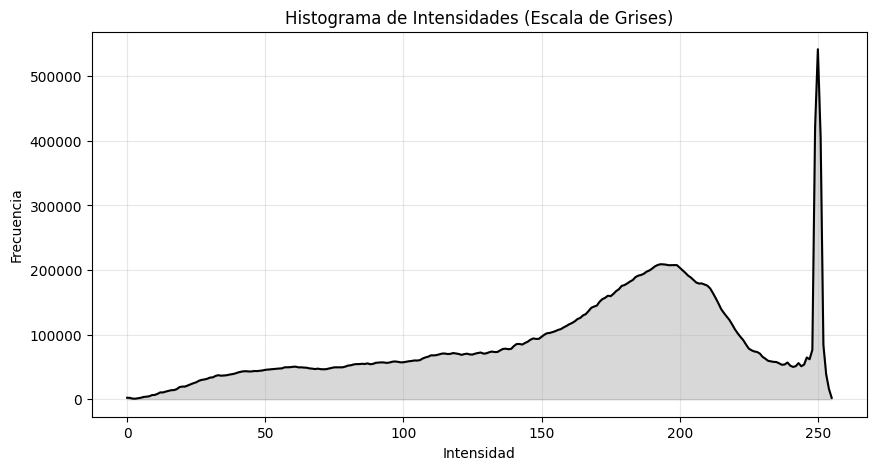

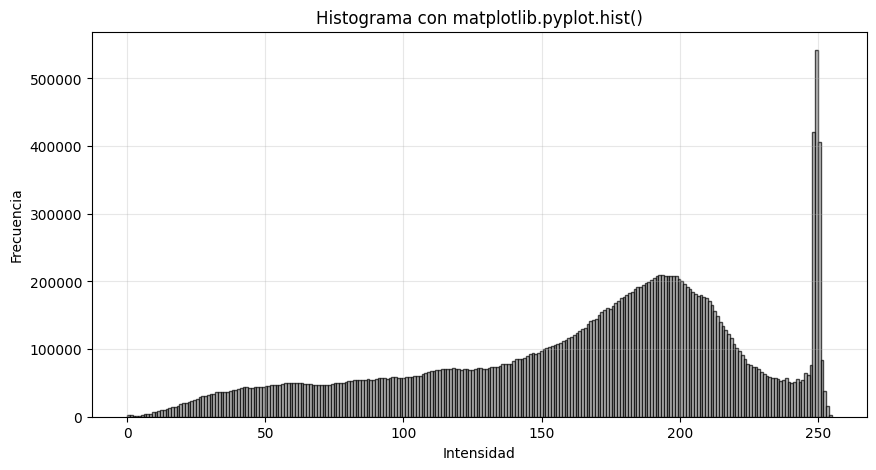

In [7]:
# Calcular histograma usando cv2.calcHist()
hist_b = cv2.calcHist([img_bgr], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([img_bgr], [1], None, [256], [0, 256])
hist_r = cv2.calcHist([img_bgr], [2], None, [256], [0, 256])

# Histograma en escala de grises (promedio de canales)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

# Mostrar histogramas RGB
plt.figure(figsize=(12, 6))
plt.plot(hist_b, color='blue', label='Azul (B)', alpha=0.7)
plt.plot(hist_g, color='green', label='Verde (G)', alpha=0.7)
plt.plot(hist_r, color='red', label='Rojo (R)', alpha=0.7)
plt.title('Histograma de Intensidades (RGB)')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../media/06_histogram_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar histograma de escala de grises
plt.figure(figsize=(10, 5))
plt.plot(hist_gray, color='black', linewidth=1.5)
plt.fill_between(range(256), hist_gray.flatten(), alpha=0.3, color='gray')
plt.title('Histograma de Intensidades (Escala de Grises)')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.savefig('../media/07_histogram_gray.png', dpi=150, bbox_inches='tight')
plt.show()

# Usar matplotlib.pyplot.hist()
plt.figure(figsize=(10, 5))
plt.hist(img_gray.flatten(), bins=256, color='darkgray', edgecolor='black', alpha=0.7)
plt.title('Histograma con matplotlib.pyplot.hist()')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.savefig('../media/08_histogram_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Aplicar ajustes de brillo y contraste

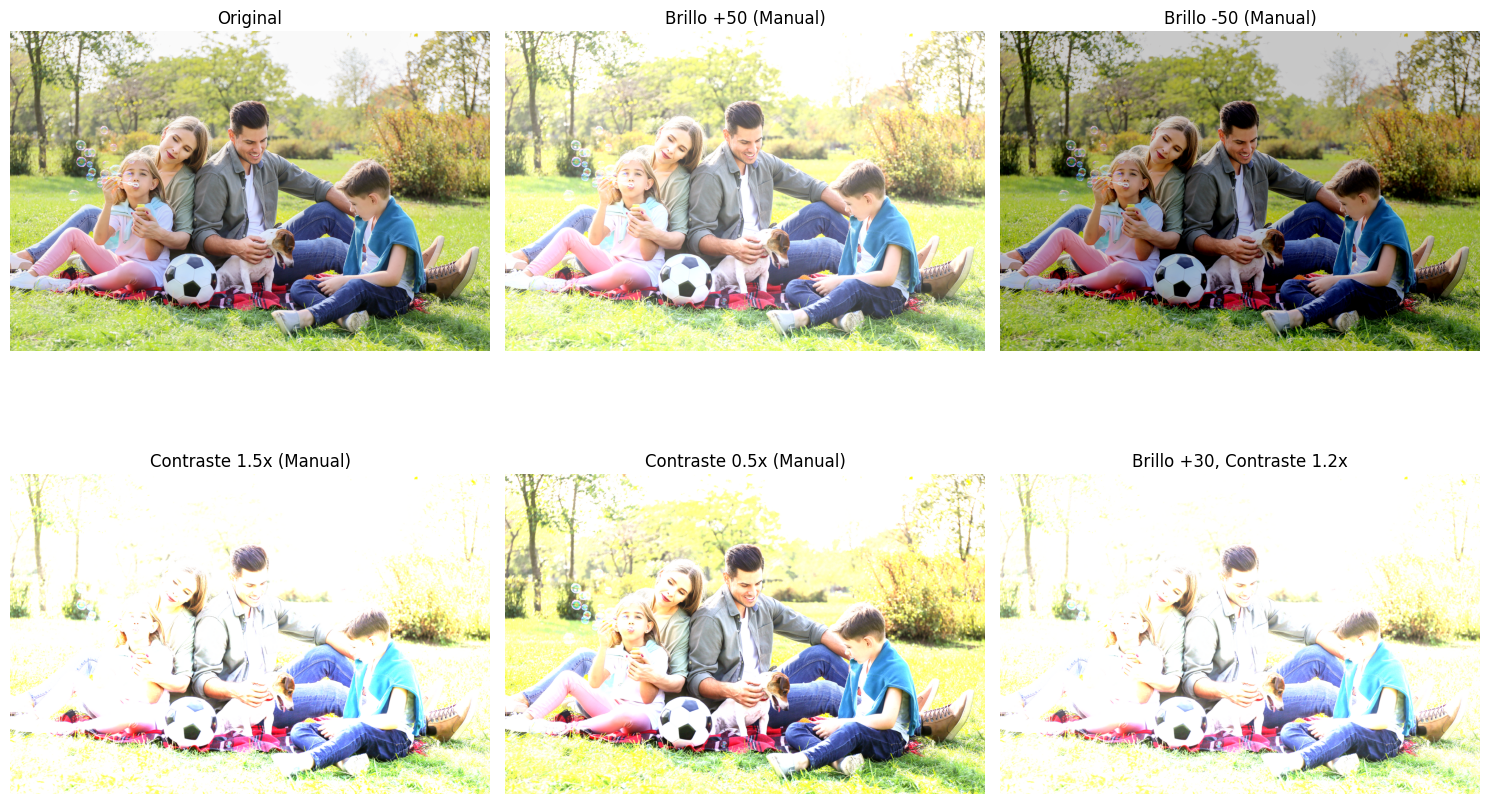

In [8]:
# Función para ajustar brillo y contraste manualmente (por ecuación)
def adjust_brightness_contrast_manual(image, brightness=0, contrast=0):
    """
    Ajusta brillo y contraste manualmente
    brillo: valor a sumar a cada píxel (-255 a 255)
    contraste: multiplicador (0 a 2)
    """
    # Aplicar contraste: (pixel - 128) * contraste + 128
    img_contrast = np.clip(image.astype(np.float32) * (contrast + 1), 0, 255)
    # Aplicar brillo: sumar valor
    img_bright = np.clip(img_contrast + brightness, 0, 255)
    return img_bright.astype(np.uint8)

# Pruebas con diferentes valores
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Brillo positivo
img_bright_pos = adjust_brightness_contrast_manual(img_bgr, brightness=50, contrast=0)
img_bright_pos_rgb = cv2.cvtColor(img_bright_pos, cv2.COLOR_BGR2RGB)
axes[0, 1].imshow(img_bright_pos_rgb)
axes[0, 1].set_title('Brillo +50 (Manual)')
axes[0, 1].axis('off')

# Brillo negativo
img_bright_neg = adjust_brightness_contrast_manual(img_bgr, brightness=-50, contrast=0)
img_bright_neg_rgb = cv2.cvtColor(img_bright_neg, cv2.COLOR_BGR2RGB)
axes[0, 2].imshow(img_bright_neg_rgb)
axes[0, 2].set_title('Brillo -50 (Manual)')
axes[0, 2].axis('off')

# Contraste alto
img_contrast_high = adjust_brightness_contrast_manual(img_bgr, brightness=0, contrast=1.5)
img_contrast_high_rgb = cv2.cvtColor(img_contrast_high, cv2.COLOR_BGR2RGB)
axes[1, 0].imshow(img_contrast_high_rgb)
axes[1, 0].set_title('Contraste 1.5x (Manual)')
axes[1, 0].axis('off')

# Contraste bajo
img_contrast_low = adjust_brightness_contrast_manual(img_bgr, brightness=0, contrast=0.5)
img_contrast_low_rgb = cv2.cvtColor(img_contrast_low, cv2.COLOR_BGR2RGB)
axes[1, 1].imshow(img_contrast_low_rgb)
axes[1, 1].set_title('Contraste 0.5x (Manual)')
axes[1, 1].axis('off')

# Brillo y contraste combinados
img_both = adjust_brightness_contrast_manual(img_bgr, brightness=30, contrast=1.2)
img_both_rgb = cv2.cvtColor(img_both, cv2.COLOR_BGR2RGB)
axes[1, 2].imshow(img_both_rgb)
axes[1, 2].set_title('Brillo +30, Contraste 1.2x')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../media/09_brightness_contrast_manual.png', dpi=150, bbox_inches='tight')
plt.show()

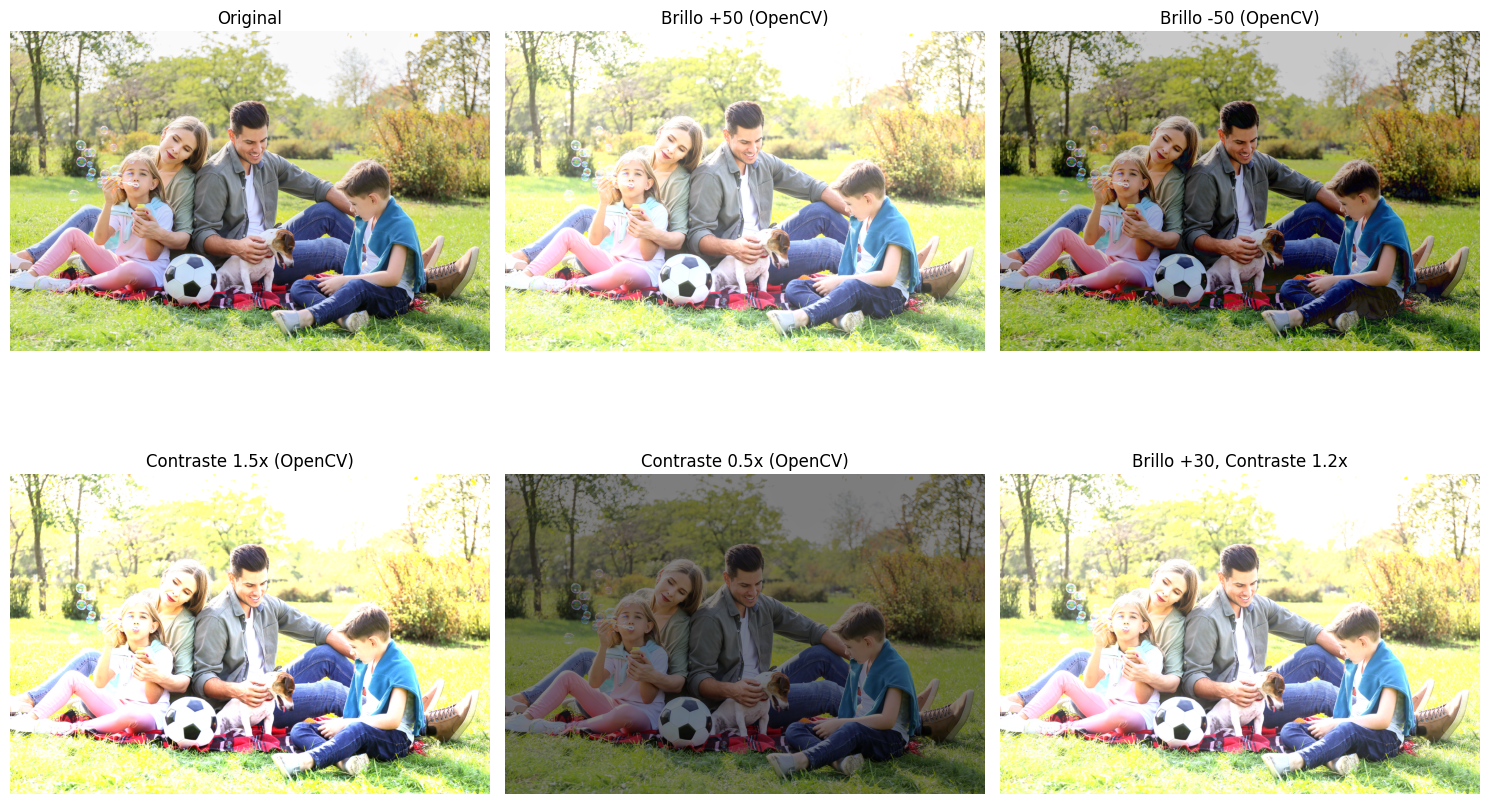

In [9]:
# Usar funciones de OpenCV (cv2.convertScaleAbs())
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# convertScaleAbs con alfa y beta
# alfa = contraste (1.0 = sin cambio), beta = brillo (0 = sin cambio)

# Brillo +50
img_cv_bright = cv2.convertScaleAbs(img_bgr, alpha=1.0, beta=50)
img_cv_bright_rgb = cv2.cvtColor(img_cv_bright, cv2.COLOR_BGR2RGB)
axes[0, 1].imshow(img_cv_bright_rgb)
axes[0, 1].set_title('Brillo +50 (OpenCV)')
axes[0, 1].axis('off')

# Brillo -50
img_cv_dark = cv2.convertScaleAbs(img_bgr, alpha=1.0, beta=-50)
img_cv_dark_rgb = cv2.cvtColor(img_cv_dark, cv2.COLOR_BGR2RGB)
axes[0, 2].imshow(img_cv_dark_rgb)
axes[0, 2].set_title('Brillo -50 (OpenCV)')
axes[0, 2].axis('off')

# Contraste 1.5
img_cv_contrast = cv2.convertScaleAbs(img_bgr, alpha=1.5, beta=0)
img_cv_contrast_rgb = cv2.cvtColor(img_cv_contrast, cv2.COLOR_BGR2RGB)
axes[1, 0].imshow(img_cv_contrast_rgb)
axes[1, 0].set_title('Contraste 1.5x (OpenCV)')
axes[1, 0].axis('off')

# Contraste 0.5
img_cv_low_contrast = cv2.convertScaleAbs(img_bgr, alpha=0.5, beta=0)
img_cv_low_contrast_rgb = cv2.cvtColor(img_cv_low_contrast, cv2.COLOR_BGR2RGB)
axes[1, 1].imshow(img_cv_low_contrast_rgb)
axes[1, 1].set_title('Contraste 0.5x (OpenCV)')
axes[1, 1].axis('off')

# Combinado
img_cv_both = cv2.convertScaleAbs(img_bgr, alpha=1.2, beta=30)
img_cv_both_rgb = cv2.cvtColor(img_cv_both, cv2.COLOR_BGR2RGB)
axes[1, 2].imshow(img_cv_both_rgb)
axes[1, 2].set_title('Brillo +30, Contraste 1.2x')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../media/10_brightness_contrast_opencv.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bonus: Función interactiva con sliders (cv2.createTrackbar)

In [10]:
# Crear ventana con trackbars para brillo y contraste
def create_interactive_brightness_contrast():
    """
    Crea una ventana interactiva con sliders para ajustar brillo y contraste
    en tiempo real usando cv2.createTrackbar()
    """
    
    # Cargar imagen
    img = img_bgr.copy()
    
    # Crear ventana
    cv2.namedWindow('Ajustes de Brillo y Contraste')
    
    # Valores iniciales
    alpha = 1.0  # Contraste
    beta = 0     # Brillo
    
    # Crear trackbars
    cv2.createTrackbar('Contraste (alfa x100)', 'Ajustes de Brillo y Contraste', 100, 300, lambda x: None)
    cv2.createTrackbar('Brillo (beta)', 'Ajustes de Brillo y Contraste', 0, 100, lambda x: None)
    
    # Valores por defecto
    cv2.setTrackbarPos('Contraste (alfa x100)', 'Ajustes de Brillo y Contraste', 100)
    cv2.setTrackbarPos('Brillo (beta)', 'Ajustes de Brillo y Contraste', 0)
    
    print("Ventana interactiva creada. Usa los sliders para ajustar brillo y contraste.")
    print("Presiona cualquier tecla para salir.")
    
    while True:
        # Obtener valores de los trackbars
        alpha_val = cv2.getTrackbarPos('Contraste (alfa x100)', 'Ajustes de Brillo y Contraste') / 100.0
        beta_val = cv2.getTrackbarPos('Brillo (beta)', 'Ajustes de Brillo y Contraste') - 50
        
        # Aplicar ajustes
        adjusted = cv2.convertScaleAbs(img, alpha=alpha_val, beta=beta_val)
        
        # Mostrar resultado
        cv2.imshow('Ajustes de Brillo y Contraste', adjusted)
        
        # Salir con cualquier tecla
        key = cv2.waitKey(1) & 0xFF
        if key != 255:
            break
    
    cv2.destroyAllWindows()
    
    # Guardar última configuración
    final_adjusted = cv2.convertScaleAbs(img, alpha=alpha_val, beta=beta_val)
    final_adjusted_rgb = cv2.cvtColor(final_adjusted, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(final_adjusted_rgb)
    plt.title(f'Resultado Final: Contraste={alpha_val}, Brillo={beta_val}')
    plt.axis('off')
    plt.savefig('../media/11_interactive_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return alpha_val, beta_val

# NOTA: Esta función requiere un entorno con GUI
# Recomendamos ejecutarla localmente con opencv-python
# En Colab usar ipywidgets + matplotlib

print("Función interactiva definida: create_interactive_brightness_contrast()")
print("Para ejecutarla en un entorno con GUI, llama: create_interactive_brightness_contrast()")

Función interactiva definida: create_interactive_brightness_contrast()
Para ejecutarla en un entorno con GUI, llama: create_interactive_brightness_contrast()


## 7. Resumen de la matriz de la imagen

In [11]:
# Analizar la matriz de la imagen
print("=" * 50)
print("ANÁLISIS DE LA MATRIZ DE LA IMAGEN")
print("=" * 50)

print(f"\nDimensiones de la imagen: {img_bgr.shape}")
print(f"  - Altura (rows): {img_bgr.shape[0]}")
print(f"  - Ancho (cols): {img_bgr.shape[1]}")
print(f"  - Canales (RGB): {img_bgr.shape[2]}")

print(f"\nTipo de datos: {img_bgr.dtype}")
print(f"Rango de valores: [{img_bgr.min()}, {img_bgr.max()}]")

print(f"\nEjemplo de píxel [100, 100]: {img_bgr[100, 100]}")
print(f"  - Canal Azul (B): {img_bgr[100, 100, 0]}")
print(f"  - Canal Verde (G): {img_bgr[100, 100, 1]}")
print(f"  - Canal Rojo (R): {img_bgr[100, 100, 2]}")

print(f"\nEstadísticas por canal:")
print(f"  B: min={b.min()}, max={b.max()}, media={b.mean():.2f}")
print(f"  G: min={g.min()}, max={g.max()}, media={g.mean():.2f}")
print(f"  R: min={r.min()}, max={r.max()}, media={r.mean():.2f}")

print("\n" + "=" * 50)
print("Taller completado exitosamente!")
print("=" * 50)

ANÁLISIS DE LA MATRIZ DE LA IMAGEN

Dimensiones de la imagen: (3840, 5760, 3)
  - Altura (rows): 3840
  - Ancho (cols): 5760
  - Canales (RGB): 3

Tipo de datos: uint8
Rango de valores: [0, 255]

Ejemplo de píxel [100, 100]: [231 228 223]
  - Canal Azul (B): 231
  - Canal Verde (G): 228
  - Canal Rojo (R): 223

Estadísticas por canal:
  B: min=0, max=255, media=134.61
  G: min=0, max=255, media=167.29
  R: min=0, max=255, media=168.93

Taller completado exitosamente!
